In [ ]:
import os

def read_txt_files_with_different_encodings(folder_path):
    # 定义常见的编码方式
    encodings = ['utf-8-sig', 'gb18030', 'gbk', 'big5', 'latin1', 'iso-8859-1']
    
    # 初始化存储文件内容和文件名的列表
    file_contents = []
    file_names = []
    
    # 遍历指定文件夹中的所有文件
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            # 尝试不同的编码方式读取文件
            for encoding in encodings:
                try:
                    with open(file_path, 'rb') as file:
                        content = file.read().decode(encoding)
                    # 如果成功读取，则存储内容并跳出循环
                    file_contents.append(content)
                    file_names.append(filename[:-4])  # 去掉.txt后缀
                    break
                except UnicodeDecodeError:
                    continue
            else:
                # 如果所有编码方式都失败，打印错误信息
                print(f"无法解码文件: {filename}")
    
    return file_contents, file_names

# 示例使用
folder_path = r'C:\Users\ASUS\Desktop\研一（下）\dlnlp\第三次大作业\jyxstxtqj_downcc.com'
contents, names = read_txt_files_with_different_encodings(folder_path)

for items in contents:
    print("文件内容:", items[500:1000])
print("文件标题:", names)

文件内容: 个剑客的故事我知道得不全。但反正是写小说，不知道原来出典的，不妨任意创造一个故事。可是连写三十三个剑侠故事的心愿，永远也完成不了的。写了第一篇《越女剑》后，第二篇《虬髯客》的小说就写不下去了。写叙述文比写小说不费力得多，于是改用平铺直叙的方式，介绍原来的故事。其中《虬髯客》、《聂隐娘》、《红线》、《昆仑奴》四个故事众所周知，不再详细叙述，同时原文的文笔极好，我没有能力译成同样简洁明丽的语体文，所以附录了原文。比较生僻的故事则将原文内容全部写了出来。这些短文写于一九七○年一月和二月，是为《明报晚报》创刊最初两个月所作。
　　一 赵处女
　　江苏与浙江到宋朝时已渐渐成为中国的经济与文化中心，苏州、杭州成为出产文化和美女的地方。但在春秋战国时期，吴人和越人却是勇决剽悍的象征。那样的轻视生死，追求生命中最后一刹那的光彩，和现代一般中国人的性格相去是这么遥远，和现代苏浙人士的机智柔和更是两个极端。在那时候，吴人越人血管中所流动的，是原始的、犷野的热血。吴越的文化是外来的。伍子胥、文种、范蠡都来自西方的楚国。勾践的另一个重要谋士计然来自北方的晋国。只有西施本色的美丽，才原来就属于浣纱溪那清澈的
文件内容: 这玩意儿比甚么游戏都好玩，转到门口，推门进去，大叫：“老师，你教我这玩意儿！”
　　这女孩儿李沅芷是总兵李可秀的独生女儿，是他在湘西做参将任内所生，给女儿取这名字，是纪念生地之意。教书先生陆高止是位饱学宿儒，五十四五岁年纪，平日与李沅芷谈古论今，师生间倒也甚是相得。这一天陆高止因受不了青蝇苦扰，发射芙蓉金针，钉死了数十只，哪知却给女弟子在窗外偷看到了。他见李沅芷一张清秀明艳的脸蛋红扑扑地显得甚是兴奋，当下淡淡的道：“唔，怎么不跟女伴去玩儿，想听诸葛亮三气周瑜的故事，是不是？”李沅芷道：“老师，你教我这好玩的法儿？”陆高止道：“甚么法儿呀？”
　　李沅芷道：“用金针钉苍蝇的法儿。”说着搬了张椅子，纵身跳上，细细瞧了一会，把钉在苍蝇身上的金针一枚枚拔下来，用纸抹拭干净，交还老师，说道：“老师，我知道，你这不是玩意儿，是非常高明的武功，你非教我不可。”她有时跟随父亲在练武场上盘马弯弓，也学过一些武艺。陆高止微笑道：“你要学武功，扶风城周围几百里地，谁也及不上你爹爹武艺高强。”李沅芷道：“我爹爹只会用弓箭射鹰，可不会用金针射苍蝇，你若不信，我便问爹爹去，看他会不会。”
　

In [2]:
import jieba
import re
import os

def load_custom_words(file_list):
    """加载自定义词汇（人名、地名等）到jieba分词词库"""
    for file in file_list:
        if os.path.exists(file):
            with open(file, 'r', encoding='utf-8') as f:
                for line in f:
                    word = line.strip()
                    if word:
                        jieba.add_word(word, freq=100000, tag='n')

def load_filter_items(file):
    """加载需要过滤的标点符号或停用词"""
    if os.path.exists(file):
        with open(file, 'r', encoding='utf-8') as f:
            return set(line.strip() for line in f if line.strip())
    return set()

def clean_text(text):
    """去除英文字符"""
    return re.sub(r'[a-zA-Z]', '', text)

def segment_novel(novel_text, punctuation_set, stopwords_set):
    """对单篇小说进行分词处理"""
    # 清洗文本
    cleaned_text = clean_text(novel_text)
    
    # 使用jieba进行分词
    words = jieba.lcut(cleaned_text)
    
    # 过滤标点符号和停用词
    filtered_words = [
        word for word in words 
        if word not in punctuation_set 
        and word not in stopwords_set
        and word.strip()
    ]
    
    return filtered_words

def process_jinyong_novels(novel_texts):
    """处理金庸小说列表"""
    # 加载自定义词汇
    custom_files = ["地名.txt", "人名.txt", "门派.txt", "武功.txt", "武器.txt"]
    load_custom_words(custom_files)
    
    # 加载需要过滤的内容
    punctuation_set = load_filter_items("cn_punctuation.txt")
    stopwords_set = load_filter_items("cn_stopwords.txt")
    i=0
    lll=len(novel_texts)
    # 处理每篇小说
    segmented_novels = []
    for novel_text in novel_texts:
        if i % 2 ==0 :
            print(f"分词已完成{i/lll*100} %")
        segmented = segment_novel(novel_text, punctuation_set, stopwords_set)
        segmented_novels.append(segmented)
        i+=1
    
    return segmented_novels

# 示例使用
if __name__ == "__main__":
    # 假设这是你的金庸小说文本列表
    jinyong_novels = contents
    
    # 处理小说
    segmented_results = process_jinyong_novels([jinyong_novels[4]])
    
    # segmented_results 现在是一个列表的列表，每个子列表包含一部小说的分词结果
    for i, novel_segments in enumerate(segmented_results):
        print(f"第{i+1}部小说的分词数量: {len(novel_segments)}")
        print("前20个分词:", novel_segments[:20])

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\86157\AppData\Local\Temp\jieba.cache
Loading model cost 0.588 seconds.
Prefix dict has been built successfully.


分词已完成0.0 %
第1部小说的分词数量: 398116
前20个分词: ['本书', '173', '免费小说', '下载站', '更', '更新', '免费', '电子书', '请', '关注', '173', '天龙八部', '少年游', '青衫', '磊落', '险峰', '行', '玉璧', '月华', '明']


In [3]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import multiprocessing
import os
import logging

# 设置日志
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

def train_word2vec(segmented_novels, output_model_name, vector_size=300, window=5, min_count=5):
    """
    训练Word2Vec模型并保存
    
    参数:
        segmented_novels: 分词后的文本列表，每个元素是一个小说的分词列表
        output_model_name: 输出模型文件名(不带后缀)
        vector_size: 词向量维度
        window: 窗口大小
        min_count: 最小词频
    """
    # 准备训练数据(临时写入文件，以便使用LineSentence高效读取)
    temp_corpus_file = "temp_corpus.txt"
    with open(temp_corpus_file, 'w', encoding='utf-8') as f:
        for novel in segmented_novels:
            f.write(' '.join(novel) + '\n')
    
    # 使用LineSentence读取语料
    sentences = LineSentence(temp_corpus_file)
    
    # 训练Word2Vec模型
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=multiprocessing.cpu_count(),
        epochs=10,
        sg=1,  # 使用skip-gram模型
        hs=0,  # 使用负采样
        negative=5,
        seed=42
    )
    
    # 保存模型
    model.save(f"{output_model_name}.model")
    model.wv.save_word2vec_format(f"{output_model_name}.bin", binary=True)
    model.wv.save_word2vec_format(f"{output_model_name}.txt", binary=False)
    
    # 删除临时文件
    os.remove(temp_corpus_file)
    
    return model

# 示例使用
if __name__ == "__main__":
    # 假设segmented_results是之前分词的结果
    # segmented_results = process_jinyong_novels(jinyong_novels)
    
    # 这里用一个简单的示例数据代替
    segmented_results1 = segmented_results
    
    # 训练Word2Vec模型
    model = train_word2vec(
        segmented_results1,
        output_model_name="jinyong_novel_word2vec",
        vector_size=800,
        window=8,
        min_count=2
    )
    
    # 测试模型
    print("\n相似词测试:")
    for word in ["郭靖", "降龙十八掌", "丐帮"]:
        if word in model.wv:
            print(f"与'{word}'最相似的词:")
            print(model.wv.most_similar(word, topn=5))
        else:
            print(f"'{word}'不在词汇表中")

2025-04-08 20:33:28,556 : INFO : collecting all words and their counts
2025-04-08 20:33:28,588 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-04-08 20:33:28,681 : INFO : collected 51209 word types from a corpus of 398116 raw words and 40 sentences
2025-04-08 20:33:28,683 : INFO : Creating a fresh vocabulary
2025-04-08 20:33:28,761 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 25792 unique words (50.37% of original 51209, drops 25417)', 'datetime': '2025-04-08T20:33:28.761501', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'prepare_vocab'}
2025-04-08 20:33:28,762 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 372699 word corpus (93.62% of original 398116, drops 25417)', 'datetime': '2025-04-08T20:33:28.762103', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, In


相似词测试:
'郭靖'不在词汇表中
与'降龙十八掌'最相似的词:
[('夺到', 0.8421187400817871), ('接一接', 0.83349609375), ('这两项', 0.8321249485015869), ('打狗棒法', 0.8298053741455078), ('十八掌', 0.8197929859161377)]
与'丐帮'最相似的词:
[('帮主', 0.7019025087356567), ('长老', 0.6596141457557678), ('帮中', 0.6284452080726624), ('宋长老', 0.6214002966880798), ('庄聚贤', 0.6198041439056396)]


In [4]:
import numpy as np
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
from itertools import combinations

# 加载训练好的Word2Vec模型
model = Word2Vec.load("jinyong_novel_word2vec.model")

# 加载天龙八部人物列表并去重
with open("天龙八部人物.txt", "r", encoding="utf-8") as f:
    characters = list(set(line.strip() for line in f if line.strip() in model.wv))
    
print(f"找到{len(characters)}个有效人物")

2025-04-08 20:34:14,945 : INFO : Note: NumExpr detected 16 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-04-08 20:34:14,945 : INFO : NumExpr defaulting to 8 threads.
2025-04-08 20:34:16,154 : INFO : loading Word2Vec object from jinyong_novel_word2vec.model
2025-04-08 20:34:16,166 : INFO : loading wv recursively from jinyong_novel_word2vec.model.wv.* with mmap=None
2025-04-08 20:34:16,166 : INFO : loading vectors from jinyong_novel_word2vec.model.wv.vectors.npy with mmap=None
2025-04-08 20:34:16,194 : INFO : loading syn1neg from jinyong_novel_word2vec.model.syn1neg.npy with mmap=None
2025-04-08 20:34:16,225 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:34:16,375 : INFO : Word2Vec lifecycle event {'fname': 'jinyong_novel_word2vec.model', 'datetime': '2025-04-08T20:34:16.375422', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.2263

找到180个有效人物


In [5]:
# 计算所有人物对的相似度
similarities = []
for char1, char2 in combinations(characters, 2):
    if char1 in model.wv and char2 in model.wv:
        sim = model.wv.similarity(char1, char2)
        similarities.append((char1, char2, sim))

# 按相似度降序排序
top_20 = sorted(similarities, key=lambda x: x[2], reverse=True)[:40]

# 打印结果
print("相似度最高的20对人物:")
for i, (char1, char2, sim) in enumerate(top_20, 1):
    print(f"{i}. {char1} - {char2}: {sim:.4f}")

相似度最高的20对人物:
1. 慧真 - 慧观: 0.9689
2. 玄念 - 玄愧: 0.9648
3. 玄鸣 - 玄石: 0.9619
4. 本参 - 本相: 0.9590
5. 耶律重元 - 耶律涅鲁古: 0.9554
6. 单季山 - 单仲山: 0.9500
7. 玄念 - 玄净: 0.9482
8. 止湛 - 止渊: 0.9467
9. 玄净 - 玄惭: 0.9443
10. 单叔山 - 单仲山: 0.9434
11. 耶律莫哥 - 耶律涅鲁古: 0.9418
12. 玄灭 - 玄净: 0.9417
13. 石清露 - 吴领军: 0.9414
14. 玄垢 - 玄净: 0.9410
15. 单季山 - 单小山: 0.9397
16. 本参 - 本观: 0.9378
17. 玄念 - 玄惭: 0.9361
18. 范纯仁 - 颇拉苏: 0.9361
19. 玄念 - 玄垢: 0.9356
20. 本相 - 本观: 0.9307
21. 单季山 - 单叔山: 0.9288
22. 平婆婆 - 瑞婆婆: 0.9273
23. 单叔山 - 单小山: 0.9267
24. 小毕 - 姜师叔: 0.9235
25. 单季山 - 方大雄: 0.9235
26. 单仲山 - 方大雄: 0.9233
27. 哲罗星 - 神山上人: 0.9230
28. 霍洞主 - 程青霜: 0.9224
29. 谭婆 - 谭公: 0.9206
30. 玄灭 - 玄惭: 0.9203
31. 老汪 - 小毕: 0.9203
32. 石清露 - 冯阿三: 0.9199
33. 颇拉苏 - 耶律涅鲁古: 0.9186
34. 赵钱孙 - 谭婆: 0.9165
35. 阿洪 - 阿胜: 0.9158
36. 吴领军 - 冯阿三: 0.9118
37. 玄垢 - 玄灭: 0.9095
38. 耶律莫哥 - 耶律重元: 0.9089
39. 玄念 - 玄灭: 0.9083
40. 秦伯起 - 姜师叔: 0.9080


2025-04-08 20:34:16,662 : INFO : loading Word2Vec object from jinyong_novel_word2vec.model
2025-04-08 20:34:16,674 : INFO : loading wv recursively from jinyong_novel_word2vec.model.wv.* with mmap=None
2025-04-08 20:34:16,674 : INFO : loading vectors from jinyong_novel_word2vec.model.wv.vectors.npy with mmap=None
2025-04-08 20:34:16,696 : INFO : loading syn1neg from jinyong_novel_word2vec.model.syn1neg.npy with mmap=None
2025-04-08 20:34:16,726 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:34:16,898 : INFO : Word2Vec lifecycle event {'fname': 'jinyong_novel_word2vec.model', 'datetime': '2025-04-08T20:34:16.898448', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'loaded'}


警告：人物'神仙姊姊'不在词向量中
警告：人物'钦岛主'不在词向量中
警告：人物'枯荣大师'不在词向量中
警告：人物'和哩布'不在词向量中
警告：人物'王维义'不在词向量中
警告：人物'元元大师'不在词向量中
警告：人物'道清大师'不在词向量中
警告：人物'芙蓉仙子'不在词向量中
警告：人物'司马岛主'不在词向量中
警告：人物'不平道长'不在词向量中
警告：人物'玄澄'不在词向量中
警告：人物'皇妃'不在词向量中
警告：人物'老贾'不在词向量中
警告：人物'玄黄子'不在词向量中
警告：人物'剑神卓不凡'不在词向量中
警告：人物'章达夫'不在词向量中
警告：人物'骆氏三雄'不在词向量中
警告：人物'黄眉大师'不在词向量中
警告：人物'长风'不在词向量中
警告：人物'南海鳄神'不在词向量中
警告：人物'安岛主'不在词向量中
警告：人物'珠崖双怪'不在词向量中
警告：人物'无涯子'不在词向量中
警告：人物'项长老'不在词向量中
警告：人物'融智大师'不在词向量中
警告：人物'都灵道长'不在词向量中
警告：人物'范晔'不在词向量中
警告：人物'觉贤大师'不在词向量中
警告：人物'完颜阿骨打'不在词向量中
警告：人物'区岛主'不在词向量中
警告：人物'七指头陀'不在词向量中
警告：人物'章虚道长'不在词向量中
警告：人物'破嗔'不在词向量中
警告：人物'柯百岁'不在词向量中
警告：人物'九翼道人'不在词向量中
警告：人物'鹤云道长'不在词向量中
警告：人物'海风子'不在词向量中
警告：人物'于洞主'不在词向量中
警告：人物'孟师叔'不在词向量中
警告：人物'五叶大师'不在词向量中
警告：人物'孤雁'不在词向量中
警告：人物'乔三槐夫妇'不在词向量中
警告：人物'宋哲宗'不在词向量中
警告：人物'神音和尚'不在词向量中
警告：人物'破疑'不在词向量中
警告：人物'钱光胜'不在词向量中
警告：人物'金二'不在词向量中
警告：人物'诸葛中'不在词向量中
警告：人物'瑞木元'不在词向量中
警告：人物'观心大师'不在词向量中
警告：人物'秦公望'不在词向量中
警告：人物'灵门禅师'不在词向量中


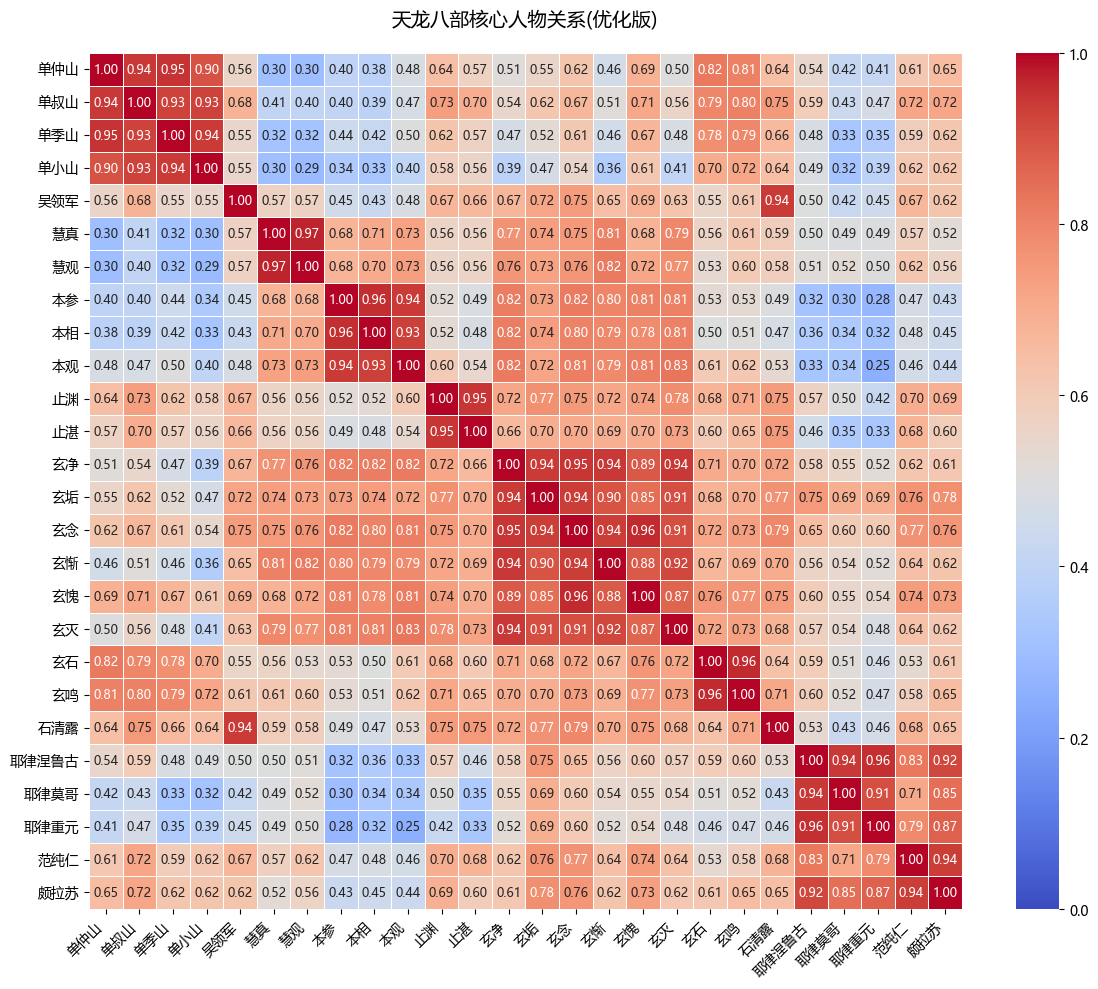

优化后的相似度矩阵已保存


In [ ]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# 1. 数据准备优化
def load_characters(char_file, model):
    """优化人物列表加载，确保名称一致且存在于模型中"""
    with open(char_file, "r", encoding="utf-8") as f:
        raw_chars = set(line.strip() for line in f)
    
    # 名称标准化处理
    char_mapping = {
        "燕远山": "萧远山",  # 修正错误名称
        "鸿擎智": "鸠摩智",
        "巅峰": "乔峰"       # 根据上下文推测
    }
    
    valid_chars = []
    for char in raw_chars:
        # 应用名称修正
        char = char_mapping.get(char, char)
        if char in model.wv:
            valid_chars.append(char)
        else:
            print(f"警告：人物'{char}'不在词向量中")
    
    return sorted(set(valid_chars))  # 确保唯一性

# 2. 相似度矩阵计算优化
def build_sim_matrix(characters, model):
    """构建无重复的相似度矩阵"""
    matrix = pd.DataFrame(
        np.zeros((len(characters), len(characters))),
        index=characters,
        columns=characters
    )
    
    # 只计算上三角矩阵，避免重复计算
    for i, char1 in enumerate(characters):
        for j in range(i, len(characters)):
            char2 = characters[j]
            sim = model.wv.similarity(char1, char2)
            matrix.at[char1, char2] = sim
            matrix.at[char2, char1] = sim  # 对称矩阵
    
    np.fill_diagonal(matrix.values, 1.0)  # 对角线设为1
    return matrix

# 3. 可视化优化
def plot_optimized_heatmap(matrix, top_n=20):
    """优化后的热力图绘制"""
    # 提取最相关的top_n对关系
    corr_pairs = []
    for i in range(len(matrix)):
        for j in range(i+1, len(matrix)):
            corr_pairs.append((matrix.index[i], matrix.columns[j], matrix.iloc[i,j]))
    
    top_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:top_n]
    top_chars = sorted(set([x[0] for x in top_pairs] + [x[1] for x in top_pairs]))
    
    # 创建子矩阵
    sub_matrix = matrix.loc[top_chars, top_chars]
    
    # 绘制
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0.5,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    plt.title("天龙八部最高相似度人物关系(优化版)", pad=20, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig("optimized_sim_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    return sub_matrix

# 主流程
if __name__ == "__main__":
    # 加载模型和人物
    model = Word2Vec.load("jinyong_novel_word2vec.model")
    characters = load_characters("天龙八部人物.txt", model)
    
    # 构建矩阵
    sim_matrix = build_sim_matrix(characters, model)
    
    # 可视化
    optimized_matrix = plot_optimized_heatmap(sim_matrix)
    
    # 保存结果
    optimized_matrix.to_csv("optimized_similarity_matrix.csv", encoding="utf-8-sig")
    print("优化后的相似度矩阵已保存")

2025-04-08 20:34:21,376 : INFO : loading Word2Vec object from jinyong_novel_word2vec.model
2025-04-08 20:34:21,386 : INFO : loading wv recursively from jinyong_novel_word2vec.model.wv.* with mmap=None
2025-04-08 20:34:21,388 : INFO : loading vectors from jinyong_novel_word2vec.model.wv.vectors.npy with mmap=None
2025-04-08 20:34:21,406 : INFO : loading syn1neg from jinyong_novel_word2vec.model.syn1neg.npy with mmap=None
2025-04-08 20:34:21,440 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:34:21,608 : INFO : Word2Vec lifecycle event {'fname': 'jinyong_novel_word2vec.model', 'datetime': '2025-04-08T20:34:21.608621', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'loaded'}


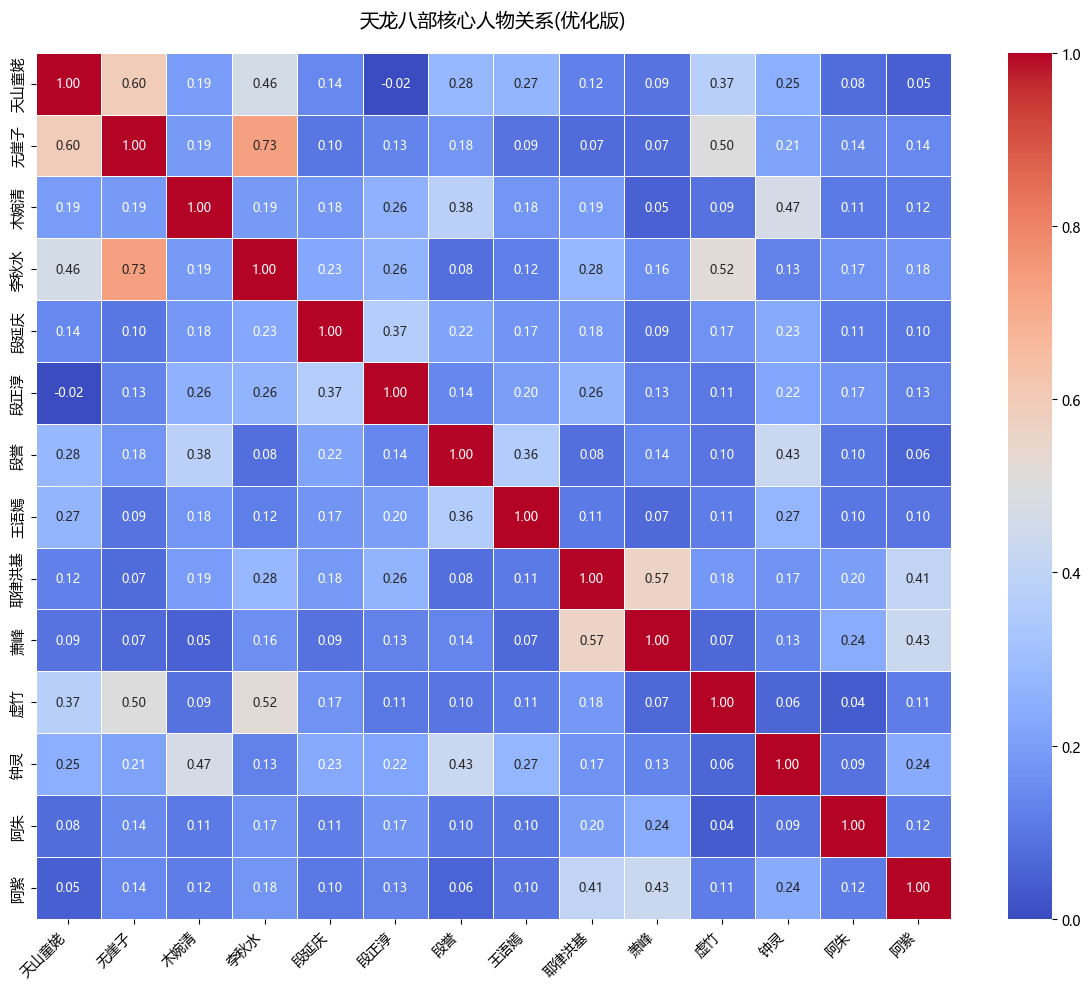

优化后的相似度矩阵已保存


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# 1. 数据准备优化
def load_characters(char_file, model):
    """优化人物列表加载，确保名称一致且存在于模型中"""
    with open(char_file, "r", encoding="utf-8") as f:
        raw_chars = set(line.strip() for line in f)
    
    # 名称标准化处理
    char_mapping = {
        "燕远山": "萧远山",  # 修正错误名称
        "鸿擎智": "鸠摩智",
        "巅峰": "乔峰"       # 根据上下文推测
    }
    
    valid_chars = []
    for char in raw_chars:
        # 应用名称修正
        char = char_mapping.get(char, char)
        if char in model.wv:
            valid_chars.append(char)
        else:
            print(f"警告：人物'{char}'不在词向量中")
    
    return sorted(set(valid_chars))  # 确保唯一性

# 2. 相似度矩阵计算优化
def build_sim_matrix(characters, model):
    """构建无重复的相似度矩阵"""
    matrix = pd.DataFrame(
        np.zeros((len(characters), len(characters))),
        index=characters,
        columns=characters
    )
    
    # 只计算上三角矩阵，避免重复计算
    for i, char1 in enumerate(characters):
        for j in range(i, len(characters)):
            char2 = characters[j]
            sim = model.wv.similarity(char1, char2)
            matrix.at[char1, char2] = sim
            matrix.at[char2, char1] = sim  # 对称矩阵
    
    np.fill_diagonal(matrix.values, 1.0)  # 对角线设为1
    return matrix

# 3. 可视化优化
def plot_optimized_heatmap(matrix, top_n=80):
    """优化后的热力图绘制"""
    # 提取最相关的top_n对关系
    corr_pairs = []
    for i in range(len(matrix)):
        for j in range(i+1, len(matrix)):
            corr_pairs.append((matrix.index[i], matrix.columns[j], matrix.iloc[i,j]))
    
    top_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:top_n]
    top_chars = sorted(set([x[0] for x in top_pairs] + [x[1] for x in top_pairs]))
    
    # 创建子矩阵
    sub_matrix = matrix.loc[top_chars, top_chars]
    
    # 绘制
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0.5,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    plt.title("天龙八部核心人物关系(优化版)", pad=20, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig("optimized_sim_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    return sub_matrix

# 主流程
if __name__ == "__main__":
    # 加载模型和人物
    model = Word2Vec.load("jinyong_novel_word2vec.model")
    characters = load_characters("天龙八部重要人物.txt", model)
    
    # 构建矩阵
    sim_matrix = build_sim_matrix(characters, model)
    
    # 可视化
    optimized_matrix = plot_optimized_heatmap(sim_matrix)
    
    # 保存结果
    optimized_matrix.to_csv("optimized_similarity_matrix.csv", encoding="utf-8-sig")
    print("优化后的相似度矩阵已保存")

In [8]:
# 计算所有人物对的相似度
similarities1 = []
characters = load_characters("天龙八部重要人物.txt", model)
for char1, char2 in combinations(characters, 2):
    if char1 in model.wv and char2 in model.wv:
        sim = model.wv.similarity(char1, char2)
        similarities1.append((char1, char2, sim))

# 按相似度降序排序
top_20 = sorted(similarities1, key=lambda x: x[2], reverse=True)[:40]

# 打印结果
print("相似度最高的20对人物:")
for i, (char1, char2, sim) in enumerate(top_20, 1):
    print(f"{i}. {char1} - {char2}: {sim:.4f}")

相似度最高的20对人物:
1. 无崖子 - 李秋水: 0.7328
2. 天山童姥 - 无崖子: 0.5967
3. 耶律洪基 - 萧峰: 0.5664
4. 李秋水 - 虚竹: 0.5188
5. 无崖子 - 虚竹: 0.5005
6. 木婉清 - 钟灵: 0.4669
7. 天山童姥 - 李秋水: 0.4624
8. 萧峰 - 阿紫: 0.4335
9. 段誉 - 钟灵: 0.4287
10. 耶律洪基 - 阿紫: 0.4061
11. 木婉清 - 段誉: 0.3821
12. 天山童姥 - 虚竹: 0.3714
13. 段延庆 - 段正淳: 0.3660
14. 段誉 - 王语嫣: 0.3590
15. 李秋水 - 耶律洪基: 0.2809
16. 天山童姥 - 段誉: 0.2790
17. 王语嫣 - 钟灵: 0.2716
18. 天山童姥 - 王语嫣: 0.2689
19. 李秋水 - 段正淳: 0.2634
20. 段正淳 - 耶律洪基: 0.2627
21. 木婉清 - 段正淳: 0.2593
22. 天山童姥 - 钟灵: 0.2531
23. 萧峰 - 阿朱: 0.2405
24. 钟灵 - 阿紫: 0.2371
25. 段延庆 - 钟灵: 0.2338
26. 李秋水 - 段延庆: 0.2297
27. 段正淳 - 钟灵: 0.2195
28. 段延庆 - 段誉: 0.2152
29. 无崖子 - 钟灵: 0.2127
30. 耶律洪基 - 阿朱: 0.2006
31. 段正淳 - 王语嫣: 0.1998
32. 天山童姥 - 木婉清: 0.1950
33. 木婉清 - 耶律洪基: 0.1925
34. 木婉清 - 李秋水: 0.1891
35. 无崖子 - 木婉清: 0.1890
36. 段延庆 - 耶律洪基: 0.1844
37. 耶律洪基 - 虚竹: 0.1833
38. 木婉清 - 段延庆: 0.1798
39. 木婉清 - 王语嫣: 0.1797
40. 李秋水 - 阿紫: 0.1785


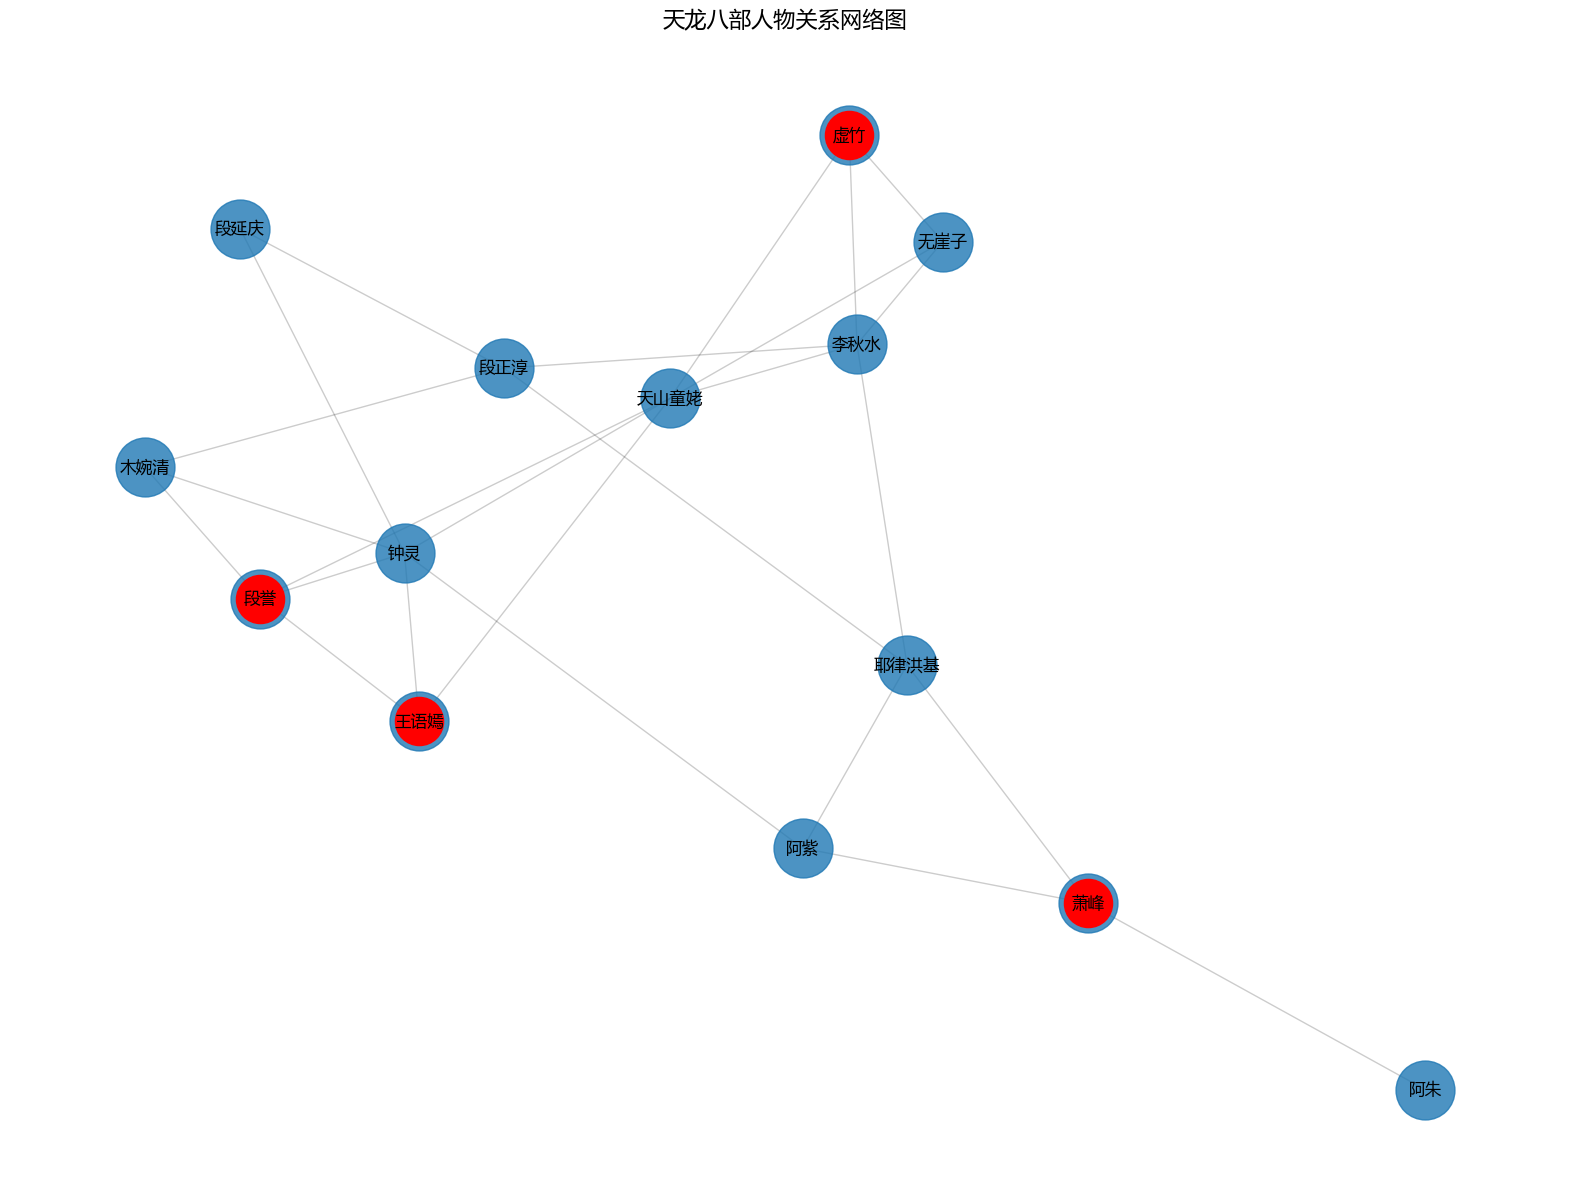

In [9]:
import networkx as nx

# 创建关系图
G = nx.Graph()
# 在代码开头添加字体设置
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 只添加相似度高于阈值的关系
threshold = np.mean([x[2] for x in similarities])/2 + 0.5*np.std([x[2] for x in similarities])/2
for char1, char2, sim in similarities1:
    if sim > threshold:
        G.add_edge(char1, char2, weight=sim)

# 绘制网络图
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw_networkx_nodes(G, pos, node_size=1800, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=12, font_family="Microsoft YaHei")

# 突出显示重要人物
important_chars = [ "萧峰","段誉", "虚竹","王语嫣"]
nx.draw_networkx_nodes(G, pos, nodelist=important_chars, node_size=1200, node_color="r")

plt.title("天龙八部人物关系网络图", fontsize=16)
plt.axis("off")
plt.savefig("character_network.png", dpi=300, bbox_inches="tight")
plt.show()

2025-04-08 20:34:24,930 : INFO : loading Word2Vec object from jinyong_novel_word2vec.model
2025-04-08 20:34:24,941 : INFO : loading wv recursively from jinyong_novel_word2vec.model.wv.* with mmap=None
2025-04-08 20:34:24,942 : INFO : loading vectors from jinyong_novel_word2vec.model.wv.vectors.npy with mmap=None
2025-04-08 20:34:24,964 : INFO : loading syn1neg from jinyong_novel_word2vec.model.syn1neg.npy with mmap=None
2025-04-08 20:34:24,988 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:34:25,146 : INFO : Word2Vec lifecycle event {'fname': 'jinyong_novel_word2vec.model', 'datetime': '2025-04-08T20:34:25.146263', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'loaded'}


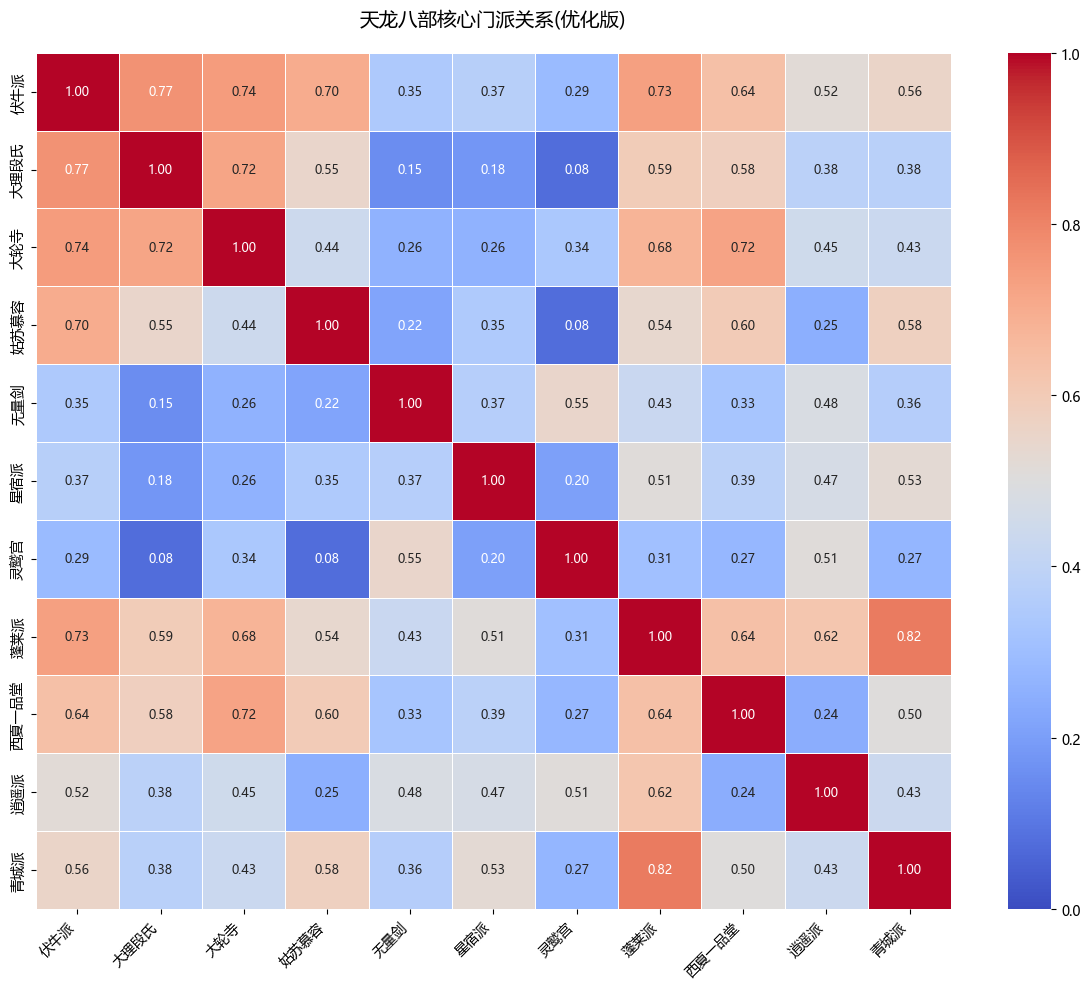

优化后的相似度矩阵已保存


In [10]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# 1. 数据准备优化
def load_characters(char_file, model):
    """优化人物列表加载，确保名称一致且存在于模型中"""
    with open(char_file, "r", encoding="utf-8") as f:
        raw_chars = set(line.strip() for line in f)
    
    # 名称标准化处理
    char_mapping = {
        "燕远山": "萧远山",  # 修正错误名称
        "鸿擎智": "鸠摩智",
        "巅峰": "乔峰"       # 根据上下文推测
    }
    
    valid_chars = []
    for char in raw_chars:
        # 应用名称修正
        char = char_mapping.get(char, char)
        if char in model.wv:
            valid_chars.append(char)
        else:
            print(f"警告：人物'{char}'不在词向量中")
    
    return sorted(set(valid_chars))  # 确保唯一性

# 2. 相似度矩阵计算优化
def build_sim_matrix(characters, model):
    """构建无重复的相似度矩阵"""
    matrix = pd.DataFrame(
        np.zeros((len(characters), len(characters))),
        index=characters,
        columns=characters
    )
    
    # 只计算上三角矩阵，避免重复计算
    for i, char1 in enumerate(characters):
        for j in range(i, len(characters)):
            char2 = characters[j]
            sim = model.wv.similarity(char1, char2)
            matrix.at[char1, char2] = sim
            matrix.at[char2, char1] = sim  # 对称矩阵
    
    np.fill_diagonal(matrix.values, 1.0)  # 对角线设为1
    return matrix

# 3. 可视化优化
def plot_optimized_heatmap(matrix, top_n=20):
    """优化后的热力图绘制"""
    # 提取最相关的top_n对关系
    corr_pairs = []
    for i in range(len(matrix)):
        for j in range(i+1, len(matrix)):
            corr_pairs.append((matrix.index[i], matrix.columns[j], matrix.iloc[i,j]))
    
    top_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:top_n]
    top_chars = sorted(set([x[0] for x in top_pairs] + [x[1] for x in top_pairs]))
    
    # 创建子矩阵
    sub_matrix = matrix.loc[top_chars, top_chars]
    
    # 绘制
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0.5,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    plt.title("天龙八部核心门派关系(优化版)", pad=20, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig("optimized_sim_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    return sub_matrix

# 主流程
if __name__ == "__main__":
    # 加载模型和人物
    model = Word2Vec.load("jinyong_novel_word2vec.model")
    characters = load_characters("天龙八部门派.txt", model)
    
    # 构建矩阵
    sim_matrix = build_sim_matrix(characters, model)
    
    # 可视化
    optimized_matrix = plot_optimized_heatmap(sim_matrix)
    
    # 保存结果
    optimized_matrix.to_csv("optimized_similarity_matrix.csv", encoding="utf-8-sig")
    print("优化后的相似度矩阵已保存")

2025-04-08 20:34:26,374 : INFO : loading Word2Vec object from jinyong_novel_word2vec.model
2025-04-08 20:34:26,382 : INFO : loading wv recursively from jinyong_novel_word2vec.model.wv.* with mmap=None
2025-04-08 20:34:26,382 : INFO : loading vectors from jinyong_novel_word2vec.model.wv.vectors.npy with mmap=None
2025-04-08 20:34:26,405 : INFO : loading syn1neg from jinyong_novel_word2vec.model.syn1neg.npy with mmap=None
2025-04-08 20:34:26,425 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:34:26,570 : INFO : Word2Vec lifecycle event {'fname': 'jinyong_novel_word2vec.model', 'datetime': '2025-04-08T20:34:26.570696', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'loaded'}


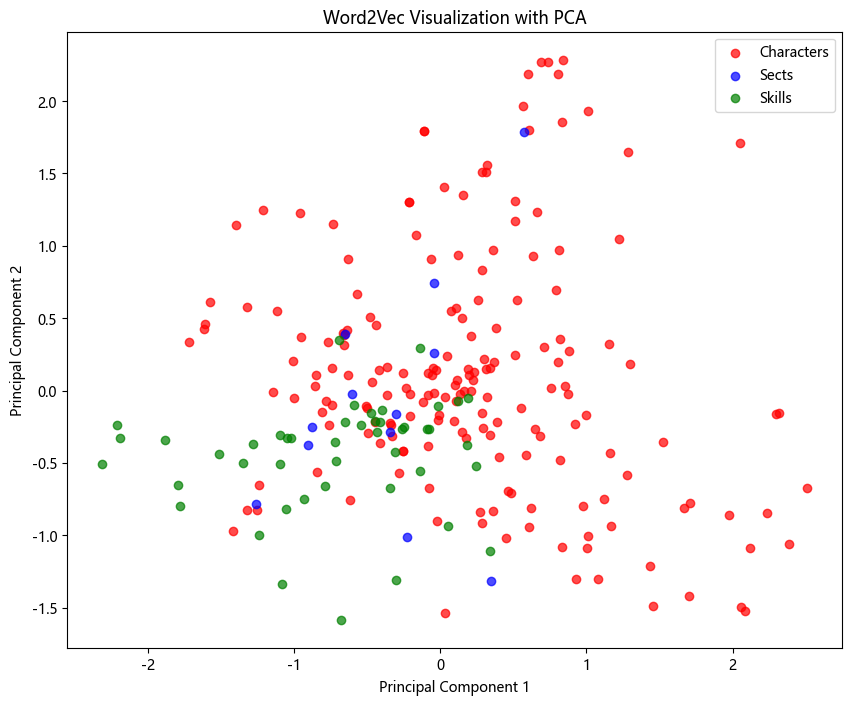

In [11]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# 加载预训练的Word2Vec模型
model = Word2Vec.load("jinyong_novel_word2vec.model")

# 定义读取文件的函数
def read_file(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        words = [line.strip() for line in f]
    return words

# 读取三个文件
characters = read_file("天龙八部人物.txt")
sects = read_file("天龙八部门派.txt")
skills = read_file("天龙八部武功.txt")

# 获取词向量
def get_word_vectors(words, model):
    vectors = []
    valid_words = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
            valid_words.append(word)
    return np.array(vectors), valid_words

char_vectors, valid_chars = get_word_vectors(characters, model)
sect_vectors, valid_sects = get_word_vectors(sects, model)
skill_vectors, valid_skills = get_word_vectors(skills, model)

# 合并所有向量
all_vectors = np.vstack([char_vectors, sect_vectors, skill_vectors])

# 使用PCA进行降维
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(all_vectors)

# 准备绘图数据
char_reduced = reduced_vectors[:len(valid_chars)]
sect_reduced = reduced_vectors[len(valid_chars):len(valid_chars)+len(valid_sects)]
skill_reduced = reduced_vectors[len(valid_chars)+len(valid_sects):]

# 绘制散点图
plt.figure(figsize=(10, 8))

plt.scatter(char_reduced[:, 0], char_reduced[:, 1], c='red', label='Characters', alpha=0.7)
plt.scatter(sect_reduced[:, 0], sect_reduced[:, 1], c='blue', label='Sects', alpha=0.7)
plt.scatter(skill_reduced[:, 0], skill_reduced[:, 1], c='green', label='Skills', alpha=0.7)

plt.title('Word2Vec Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

2025-04-08 20:39:09,916 : INFO : loading Word2Vec object from jinyong_novel_word2vec.model
2025-04-08 20:39:09,926 : INFO : loading wv recursively from jinyong_novel_word2vec.model.wv.* with mmap=None
2025-04-08 20:39:09,927 : INFO : loading vectors from jinyong_novel_word2vec.model.wv.vectors.npy with mmap=None
2025-04-08 20:39:09,945 : INFO : loading syn1neg from jinyong_novel_word2vec.model.syn1neg.npy with mmap=None
2025-04-08 20:39:09,968 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:39:10,109 : INFO : Word2Vec lifecycle event {'fname': 'jinyong_novel_word2vec.model', 'datetime': '2025-04-08T20:39:10.109350', 'gensim': '4.3.0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'loaded'}
d:\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.wa

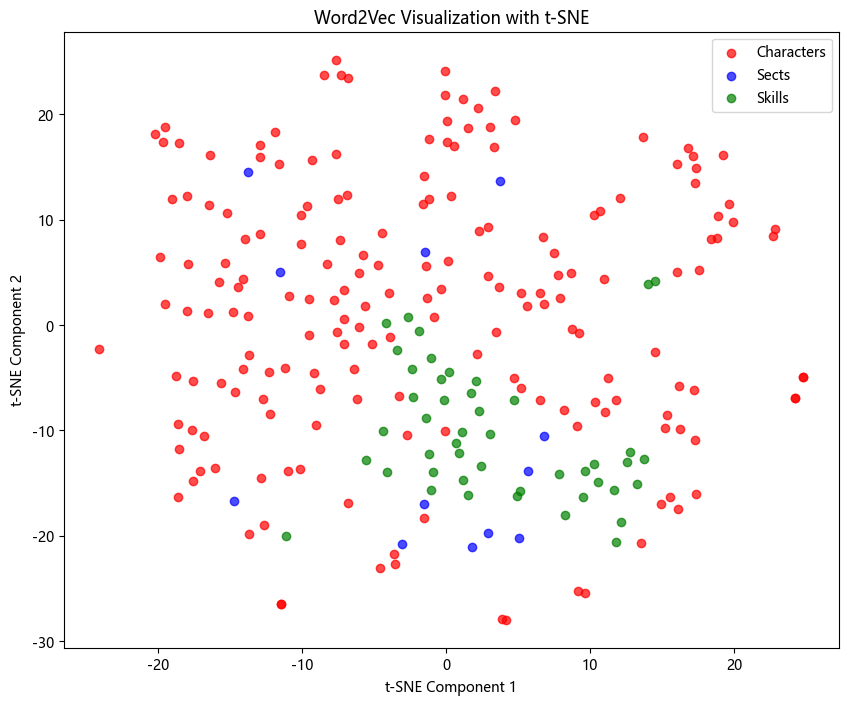

In [21]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# 加载预训练的Word2Vec模型
model = Word2Vec.load("jinyong_novel_word2vec.model")

# 定义读取文件的函数
def read_file(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        words = [line.strip() for line in f]
    return words

# 读取三个文件
characters = read_file("天龙八部人物.txt")
sects = read_file("天龙八部门派.txt")
skills = read_file("天龙八部武功.txt")

# 获取词向量
def get_word_vectors(words, model):
    vectors = []
    valid_words = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
            valid_words.append(word)
    return np.array(vectors), valid_words

char_vectors, valid_chars = get_word_vectors(characters, model)
sect_vectors, valid_sects = get_word_vectors(sects, model)
skill_vectors, valid_skills = get_word_vectors(skills, model)

# 合并所有向量
all_vectors = np.vstack([char_vectors, sect_vectors, skill_vectors])

# 使用t-SNE进行降维
tsne = TSNE(n_components=2, random_state=42, perplexity=20, n_iter=10000)
reduced_vectors = tsne.fit_transform(all_vectors)

# 准备绘图数据
char_reduced = reduced_vectors[:len(valid_chars)]
sect_reduced = reduced_vectors[len(valid_chars):len(valid_chars)+len(valid_sects)]
skill_reduced = reduced_vectors[len(valid_chars)+len(valid_sects):]

# 绘制散点图
plt.figure(figsize=(10, 8))

plt.scatter(char_reduced[:, 0], char_reduced[:, 1], c='red', label='Characters', alpha=0.7)
plt.scatter(sect_reduced[:, 0], sect_reduced[:, 1], c='blue', label='Sects', alpha=0.7)
plt.scatter(skill_reduced[:, 0], skill_reduced[:, 1], c='green', label='Skills', alpha=0.7)

plt.title('Word2Vec Visualization with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()